(disegnare-grafici)=
# Disegnare grafici
Il modulo `plt` può essere usato per produrre vari tipi di grafici. In generale
le funzioni di questo modulo che generano un grafico basato su una serie di
punti accettano come argomenti due liste contenenti rispettivamente le ascisse
e le ordinate dei punti stessi. La funzione `get_sorted_counts` restituisce
però una lista di coppie e non due liste di valori singoli. Se interpretiamo
questa lista come una matrice, la trasposta di quest'ultima equivarrà a una
lista che contiene esattamente le due liste che ci interessano. Per effettuare
questa operazione risulta conveniente utilizzare il tipo di dato base messo a
disposizione da numpy, `np.array`. Passando una lista (o una tupla, una lista
di liste e così via) come argomento a `np.array` si crea un oggetto che
corrisponde al corrispondente array. Su questo oggetto è possibile invocare
il metodo `transpose` che restituisce il trasposto dell'array.


```{admonition} Nomenclatura
:class: naming
Tecnicamente, il metodo `transpose` restituisce una **vista** dell'array
originale in modo che questo appaia trasposto. Ciò significa che non viene
creato un nuovo oggetto e quindi le modifiche fatte al valore restituito
andranno ad alterare anche l'array di partenza.

Va anche notato il fatto che se si tenta di trasporre un array monodimensionale
`transpose` restituirà una vista identica all'argomento specificato.
```

In [1]:
import numpy as np

def get_sorted_counts(sequence):
    counts = {}

    for x in sequence:
        if x in counts:
            counts[x] += 1
        else:
            counts[x] = 1

    pairs = counts.items()
    return sorted(pairs, key=lambda p:p[1], reverse=True)

years = [1941, 1962, None, None, 1941,
         1964, None, 1940, 1941, 1961,
         None, 1963, None, 1963, 1981,
         None, None, 1962, 1979]

np.array(get_sorted_counts(years)).transpose()

array([[None, 1941, 1962, 1963, 1964, 1940, 1961, 1981, 1979],
       [7, 3, 2, 2, 1, 1, 1, 1, 1]], dtype=object)

In [2]:
np.array(get_sorted_counts(years)[1:]).transpose()

array([[1941, 1962, 1963, 1964, 1940, 1961, 1981, 1979],
       [   3,    2,    2,    1,    1,    1,    1,    1]])

Va notato come la prima coppia restituita da `get_sorted_counts` sia stata
scartata tramite uno _slicing_ in quanto fa riferimento a `None` e non a un
anno, perché descrive il numero di casi in cui l'anno è un dato mancante.
Usando una caratteristica di python è possibile assegnare le due liste ottenute
direttamente a due variabili `x` e `y`:

In [3]:
a, b = (42, 102)

In [4]:
x, y = np.array(get_sorted_counts(years)[1:]).transpose()

```{admonition} Nomenclatura
:class: naming
Questa caratteristica di python, nota con il nome di _unpacking_, permette per
esempio di scambiare i contenuti di due variabili `a` e `b` senza ricorrere a
una variabile temporanea, utilizzando l'assegnamento `a, b = b, a`.
```

Le due variabili `x` e `y` possono dunque essere passate come argomento al
metodo `plt.bar` per produrre un grafico a barre che visualizzi le frequenze
assolute degli anni di prima apparizione:

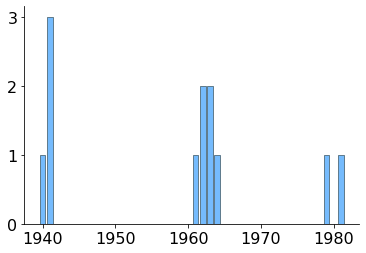

In [5]:
import matplotlib.pyplot as plt
plt.style.use('sds.mplstyle')

plt.bar(x, y)
plt.show()

Vale la pena commentare in modo approfondito le righe di codice appena
eseguite, specificando la differenza tra _generare_ e _visualizzare_ un
grafico. In generale, invocare un metodo in matplotlib ha l'effetto di
_modificare_ l'aspetto di un grafico (partendo ovviamente da un grafico vuoto).
Ciò permette di sovrapporre diversi grafici, o di cambiare le etichette sugli
assi e così via. Metodi come `plt.bar` visualizzano il grafico che corrisponde
alla modifica apportata dal metodo eseguito, restituendo nel contempo
dell'output testuale (una descrizione delle varie componenti del grafico
stesso) che nella maggior parte dei casi non è particolarmente interessante.
È per questo che l'ultima istruzione eseguita è `plt.show()`: questo metodo
visualizza il grafico senza restituire alcunché.

La prima linea di codice fa riferimento a una caratteristica speciale di
jupyter: tutte le linee che iniziano con il carattere `%` vengono chiamate
_line magic_ e permettono di effettuare operazioni accessorie, come per esempio
l'interfacciamento con le operazioni di shell. In questo caso si tratta di una
_matplotlib magic_ che specifica che i grafici prodotti da matplotlib devono
essere visualizzati direttamente nel notebook (senza questa operazione i
grafici non verrebbero mostrati automaticamente e sarebbe necessario invocare
altri metodi di matplotlib, per esempio per salvare i grafici su file system).
Infine, la seconda linea ci permette di impostare le dimensioni dei grafici: i
valori predefiniti genererebbero infatti delle figure un po' troppo grandi.

```{admonition} Nomenclatura
:class: naming
È sufficiente specificare la matplotlib magic una sola volta, all'inizio del
notebook oppure prima di produrre il primo grafico da visualizzare. Da quel
punto in avanti tutti i grafici verranno automaticamente mostrati nel notebook.
```